# Summarize and Answer: Two NLP Applications, Evaluated Honestly

## 📚 Learning Objectives

By completing this notebook, you will:
- Build an **extractive summarizer** from the TF-IDF and cosine machinery of Units 2-3 — no new library, no download
- Turn the same index into a **question-answering baseline** that returns the best-matching sentence
- **Evaluate both** against a human-written reference with a stated metric, a stated denominator and a baseline
  that must be beaten — and read the failures, because the failures are the lesson

## 🔗 Where this fits

**Builds on:** Unit 2, `enrichment/E4_retrieval_in_sixty_seconds.ipynb` (TF-IDF + cosine as a retriever) and
Unit 3, `01_text_classification.ipynb` (`TfidfVectorizer`, and what the sparse matrix actually holds). The
tokenizer choices of Unit 1 return here as a failure you can print.

**Used later in:** Course 10 (AIAT 124) Unit 2, `06_evaluating_text_quality_bleu_perplexity.ipynb` — the same
reference-metric-denominator discipline applied to *generated* text; and the Course 12 project, where any
summary or question-answering feature must ship with an evaluation shaped like Part 3 of this notebook.

---

## 🌍 Why this matters: the best-matching passage was a joke

In May 2024 Google's search began showing "AI Overviews" — a paragraph generated on top of retrieved web
passages. Within days, one query about cheese sliding off pizza returned an Overview recommending adding
*"⅛ cup of non-toxic glue to the sauce to give it more tackiness"*. The passage it had retrieved was an
eleven-year-old Reddit comment written as a joke (Daily Dot, 23 May 2024). Google's own account a week later
(Reid, 30 May 2024) named the mechanism rather than the model: forums *"are often a great source of authentic,
first-hand information, but in some cases can lead to less-than-helpful advice, like using glue to get cheese
to stick to pizza"*, and some queries hit a *"data void"* — a topic on which practically no good content exists,
so the best-matching passage is served anyway.

Notice what did **not** fail. The retriever did its job: of everything on the web, that comment really was the
best lexical match for "cheese not sticking to pizza". What failed is the step nobody had measured — the
assumption that *the best-matching passage is an answer*. Part 2 of this notebook builds exactly that kind of
retriever on 1,781 real posts, and Part 3 shows it returning a sentence with a similarity score of **1.000**
that answers nothing at all. The system in the news and the system on your laptop break in the same place.

Extractive summarization, Part 1, is older than most of the people in the room: H. P. Luhn built it at IBM in
1958 by ranking sentences on a "significance factor" computed from word frequency. What you add today is
the part Luhn could not do on an IBM 704 — evaluate it against a human reference on hundreds of documents
in a second.

## 📥 Inputs & 📤 Outputs

**Inputs:** the 20 Newsgroups collection — real Usenet posts from 1993 — restricted to three groups
(`sci.space`, `sci.med`, `rec.autos`), training split: **1,781 posts**, read from scikit-learn's local cache
(the classroom machines already have it; a fresh machine downloads about 14 MB once). The human-written
reference for each post is free and already inside the file: the author's own **Subject line**.

**Outputs:** a two-sentence extractive summary of any post; a sentence retriever that answers a question with
the best-matching sentence and its source post; ROUGE-1 recall for three summarizers on the same posts with
the same length budget; hit@1 on twelve labelled questions; two figures; and a token count per post so the
build-or-buy question in **💬 Discuss** has a number in it.

---

## Part 1: Extractive summarization from the machinery you already have

An *extractive* summary is made of sentences copied from the document, unchanged. The whole method is one
decision: **how to score a sentence**. Luhn (1958) scored by counting significant words. We use what Unit 3
built: turn the post into a TF-IDF vector, turn each of its sentences into a TF-IDF vector *with the same
vectorizer*, and keep the sentences whose vectors point most nearly in the same direction as the whole post.
Nothing is trained. The IDF is learned over all 1,781 posts, so a word scores highly in a sentence when it is
frequent in this post and rare across the others — exactly the definition from Unit 3.

In [1]:
import re
import numpy as np
from sklearn.datasets import fetch_20newsgroups

GROUPS = ["sci.space", "sci.med", "rec.autos"]


def load_posts():
    """Two views of the same posts: one with headers (for the Subject line), one body-only.

    Cache first, so a classroom machine never touches the network; the one download
    (about 14 MB) happens only on a fresh machine such as Colab, and it is announced.
    """
    for download in (False, True):
        kw = dict(subset="train", categories=GROUPS, shuffle=False, download_if_missing=download)
        try:
            with_headers = fetch_20newsgroups(remove=(), **kw)
            bodies = fetch_20newsgroups(remove=("headers", "footers", "quotes"), **kw)
        except OSError:
            continue
        print("20 Newsgroups:", "downloaded just now (about 14 MB)." if download
              else "read from the local scikit-learn cache, no network.")
        return with_headers, bodies
    raise RuntimeError(
        "20 Newsgroups is neither cached nor downloadable from here. On a machine with a "
        "network run once:  from sklearn.datasets import fetch_20newsgroups; "
        "fetch_20newsgroups(subset='train')  — then re-run this cell.")


with_headers, bodies = load_posts()


def subject_of(raw_post):
    m = re.search(r"^Subject:\s*(.*)$", raw_post, re.M)
    return m.group(1).strip() if m else ""


def split_sentences(text):
    # Usenet posts wrap lines by hand, so flatten the whitespace before splitting after . ! ?
    # Anything under 4 words is almost always a signature line or a fragment, so it is dropped.
    flat = re.sub(r"\s+", " ", text).strip()
    return [s for s in re.split(r"(?<=[.!?])\s+", flat) if len(s.split()) >= 4]


subjects = [subject_of(p) for p in with_headers.data]
doc_sents = [split_sentences(b) for b in bodies.data]
n_sents = np.array([len(s) for s in doc_sents])

print(f"posts: {len(subjects):,}   groups: {', '.join(with_headers.target_names)}")
print(f"sentences: {n_sents.sum():,}   per post: median {np.median(n_sents):.0f}, "
      f"max {n_sents.max()}   posts with no usable sentence: {(n_sents == 0).sum()}")
print(f"subjects that begin with 'Re:' (replies): {np.mean([s.lower().startswith('re:') for s in subjects]):.0%}")


def find_post(subject_start):
    """Locate a post by the start of its Subject line, so the examples below read as text, not as indices."""
    hits = [i for i, s in enumerate(subjects) if s.startswith(subject_start)]
    if not hits:
        raise KeyError(f"No post whose Subject starts with {subject_start!r}")
    return hits[0]


i = find_post("Renting from Alamo")
print(f"\nOne post as it really arrives (Subject: {subjects[i]!r}):\n")
print(bodies.data[i][:520])
print(f"\n-> {len(doc_sents[i])} sentences after splitting; the first two:")
for s in doc_sents[i][:2]:
    print("   -", s)

20 Newsgroups: read from the local scikit-learn cache, no network.
posts: 1,781   groups: rec.autos, sci.med, sci.space
sentences: 16,300   per post: median 5, max 237   posts with no usable sentence: 75
subjects that begin with 'Re:' (replies): 72%

One post as it really arrives (Subject: 'Renting from Alamo'):

Hello netters!

I'm visiting the US (I'm from Sweden) in August. I will probably rent a Chevy
Beretta from Alamo. I've been quoted $225 for a week/ $54 for additional days. 
This would include free driving distance, but not local taxes (Baltimore). 
They also told me all insurance thats necessary is included, but I doubt that,
 'cause a friend rented a car last year and it turned out he needed a lot more
insurance than what's included in the base price. But on the other hand he didn't
rent it from Alamo.

Does anyo

-> 10 sentences after splitting; the first two:
   - I'm visiting the US (I'm from Sweden) in August.
   - I will probably rent a Chevy Beretta from Alamo.


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vec = TfidfVectorizer(stop_words="english", sublinear_tf=True)
POSTS = vec.fit_transform(bodies.data)          # one row per post; the IDF is learned over posts


def score_sentences(i):
    """Cosine between each sentence of post i and the whole post, both as TF-IDF vectors.

    Cosine rather than Luhn's sum of word weights: a sum grows with sentence length, so
    it would hand the summary to the longest sentence every time. Cosine is length-free.
    """
    if not doc_sents[i]:
        return np.zeros(0)
    return cosine_similarity(vec.transform(doc_sents[i]), POSTS[i]).ravel()


def summarize(i, k=2):
    scores = score_sentences(i)
    keep = sorted(np.argsort(-scores)[:k])      # back into reading order: a summary is read, not ranked
    return [doc_sents[i][j] for j in keep]


print(f"vocabulary: {len(vec.vocabulary_):,} words   matrix: {POSTS.shape[0]:,} posts x {POSTS.shape[1]:,} words")

for start in ("HST Servicing Mission Scheduled", "Renting from Alamo", "What's the Difference Between an M.D."):
    i = find_post(start)
    print("\n" + "=" * 96)
    print(f"Subject : {subjects[i]}    ({len(doc_sents[i])} sentences)")
    for s in summarize(i):
        print(f"  * {s[:230]}{'...' if len(s) > 230 else ''}")

vocabulary: 24,513 words   matrix: 1,781 posts x 24,513 words

Subject : HST Servicing Mission Scheduled for 11 Days    (18 sentences)
  * April 23, 1993 (Phone: 202/358-1780) Kyle Herring Johnson Space Center, Houston (Phone: 713/483-5111) RELEASE: 93-76 HUBBLE TELESCOPE SERVICING MISSION SCHEDULED FOR ELEVEN DAYS The December flight of Endeavour on Space Shuttle mi...
  * "It improves the probabilities for mission success while providing added flexibility and adaptability for reacting to real-time situations." In laying out the specific tasks to be completed on each of the spacewalks, officials hav...

Subject : Renting from Alamo    (10 sentences)
  * I will probably rent a Chevy Beretta from Alamo.
  * They also told me all insurance thats necessary is included, but I doubt that, 'cause a friend rented a car last year and it turned out he needed a lot more insurance than what's included in the base price.

Subject : What's the Difference Between an M.D. and a D.O.?    (12 sentences

**Read the output before the figure.** The Hubble post is a NASA press release, and the summarizer's first
pick is the release *header* — names, phone numbers, "RELEASE: 93-76" — glued by the sentence splitter to the
first real sentence, because the press release has no full stop after "ELEVEN DAYS". Real text does that.
The high score is not a bug in the code either; it is the method working as designed. Names and numbers are rare across the 1,781 posts, rare words carry high IDF,
and a sentence packed with them looks maximally "about this post" to the mathematics while telling a reader
nothing. Keep that in mind: every scoring rule has a kind of sentence it over-values.

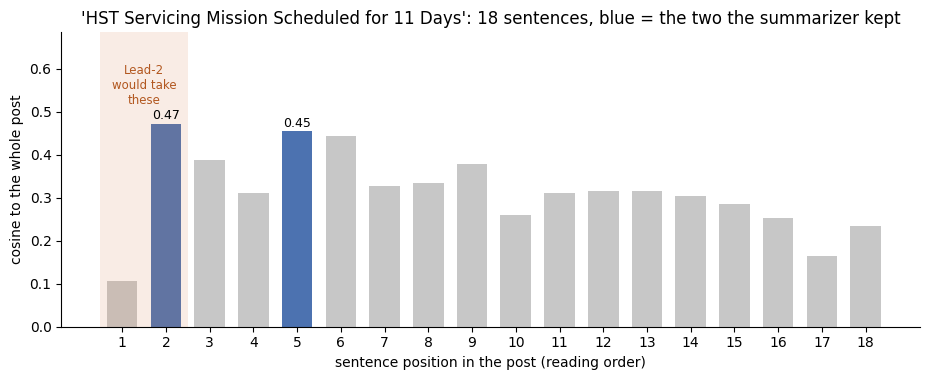

In [3]:
import matplotlib.pyplot as plt

i = find_post("HST Servicing Mission Scheduled")
scores = score_sentences(i)
kept = set(np.argsort(-scores)[:2])
pos = np.arange(1, len(scores) + 1)

fig, ax = plt.subplots(figsize=(9.4, 3.9))
ax.bar(pos, scores, width=0.7, color=["#4C72B0" if j in kept else "0.78" for j in range(len(scores))])
for j in kept:
    ax.text(pos[j], scores[j] + 0.01, f"{scores[j]:.2f}", ha="center", fontsize=9)
ax.axvspan(0.5, 2.5, color="#DD8452", alpha=0.15, lw=0)        # where a Lead-2 summary would look
ax.text(1.5, scores.max() * 1.08, "Lead-2\nwould take\nthese", ha="center", va="bottom", fontsize=8.5,
        color="#B2571F")
ax.set_ylim(0, scores.max() * 1.45)
ax.set_xticks(pos)
ax.set_xlabel("sentence position in the post (reading order)")
ax.set_ylabel("cosine to the whole post")
ax.set_title(f"'{subjects[i]}': {len(scores)} sentences, blue = the two the summarizer kept")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Read the figure.** One bar per sentence, in the order a reader meets them. The two blue bars are the
summary: position 2 (the press-release header) and position 5 (a quotation about "probabilities for mission
success"). The orange band is what the simplest possible summarizer — *take the first two sentences*, called
**Lead-2** — would have chosen, and sentence 1 ("Ed Campion Headquarters, Washington, D.C.") is the lowest
bar in the whole post. So on this document the two methods disagree almost completely. Part 3 asks the only
question that matters: over hundreds of posts, which one is closer to what a human wrote?

---

## Part 2: The same index, asked a question

Question answering by retrieval is Part 1 turned sideways. In Part 1 the "query" was the whole post and the
candidates were its own sentences. Now the query is a **question typed by a user**, the candidates are **every
sentence in every post** — 16,300 of them — and the answer is whichever sentence points most nearly the
same way as the question. Same vectorizer, same vocabulary, same cosine. This is the retrieval stage of the
retrieve-then-generate pipeline from Unit 2's `E4`, without the generate.

In [4]:
sentences = [s for ss in doc_sents for s in ss]
sent_post = [i for i, ss in enumerate(doc_sents) for _ in ss]     # which post each sentence came from
INDEX = vec.transform(sentences)                                  # the Part 1 vectorizer, unchanged


def answer(question, k=3):
    """The k sentences closest to the question, each with its source post and score."""
    scores = cosine_similarity(vec.transform([question]), INDEX).ravel()
    top = np.argsort(-scores)[:k]
    return [(sentences[j], subjects[sent_post[j]], float(scores[j])) for j in top]


def show(question, k=3):
    print("=" * 96)
    print(f"Q: {question}")
    print(f"   query words the index can see: {vec.build_analyzer()(question)}")
    for rank, (sent, subj, score) in enumerate(answer(question, k), 1):
        print(f"  {rank}. score {score:.3f}  [{subj[:44]}]")
        print(f"     {sent[:150]}{'...' if len(sent) > 150 else ''}")


print(f"index: {INDEX.shape[0]:,} sentences x {INDEX.shape[1]:,} words\n")
show("When was the Hubble telescope launched?")
show("What is the placebo effect?")

index: 16,300 sentences x 24,513 words

Q: When was the Hubble telescope launched?
   query words the index can see: ['hubble', 'telescope', 'launched']
  1. score 0.412  [HST Servicing Mission Scheduled for 11 Days]
     The telescope was launched aboard Discovery in April 1990.
  2. score 0.352  [Space FAQ 02/15 - Network Resources]
     Mike Rose (mrose@stsci.edu) posts orbital elements for the Hubble Space Telescope to sci.astro.
  3. score 0.333  [End of the Space Age]
     The reality that much of the civilian space program - from the shuttle to the Hubble telescope to the space station - was poorly conceived and unimpre...
Q: What is the placebo effect?
   query words the index can see: ['placebo', 'effect']
  1. score 0.800  [Re: Good Grief!  (was Re: Candida Albicans: ]
     Ever heard of something called the placebo effect?
  2. score 0.479  [Re: Frequent nosebleeds]
     I probably destroyed the placebo effect from my skeptical sputtering.
  3. score 0.472  [Placebo effects]

Two questions, two different outcomes, and the printed *query words* line explains both. "When was the Hubble
telescope launched?" survives the stop-word filter as three content words, and the sentence that shares two of
them — *telescope*, *launched* — is the right one even though it never says "Hubble". "What is the placebo
effect?" shrinks to two words, and the best match is a sentence that contains both and **asks the same
question back**. A lexical retriever has no idea what a question is; it only knows which words are shared.

---

## Part 3: The honest evaluation

An unevaluated summarizer is a demo. To evaluate you need three things, and each is a choice you must be able
to defend in front of a colleague:

1. **A reference written by a human.** We use the post's own Subject line. It is free, it is real, and it is
   imperfect — a reply's Subject describes the *thread*, so replies (the majority of posts) are excluded.
2. **A metric with a denominator.** **ROUGE-1 recall** (Lin, 2004): the share of the reference's content
   words that the summary contains. Denominator: the number of content words in the Subject line, median 3.
   It counts words, not meaning, and it says so in its name.
3. **A baseline that must be beaten.** Two: **Lead-2**, the first two sentences; and **Random-2**, two
   sentences drawn at random, run five times with five seeds so its spread is visible. All three methods get
   the same budget of two sentences, so the comparison is fair on length.

Random draws are the *point* of the Random-2 baseline — that is the one place randomness belongs in this
notebook.

In [5]:
analyzer = vec.build_analyzer()             # the SAME tokenizer and stop-word list the index uses


def content_words(text):
    return set(analyzer(text))


def rouge1_recall(summary_sentences, reference):
    """Share of the reference's content words that appear anywhere in the summary (Lin, 2004)."""
    ref = content_words(reference)
    got = set().union(*(content_words(s) for s in summary_sentences)) if summary_sentences else set()
    return len(ref & got) / len(ref)


EVAL = [i for i, s in enumerate(subjects)
        if not s.lower().startswith("re:")      # a reply's Subject names the thread, not the reply
        and len(doc_sents[i]) >= 3              # so that "2 of N" is a real choice
        and content_words(s)]                   # a Subject with no content word cannot be scored

tfidf_r = np.array([rouge1_recall(summarize(i), subjects[i]) for i in EVAL])
lead_r = np.array([rouge1_recall(doc_sents[i][:2], subjects[i]) for i in EVAL])
random_means = []
for seed in range(5):
    rng = np.random.default_rng(seed)
    picks = [[doc_sents[i][j] for j in sorted(rng.choice(len(doc_sents[i]), 2, replace=False))] for i in EVAL]
    random_means.append(np.mean([rouge1_recall(p, subjects[i]) for p, i in zip(picks, EVAL)]))
random_means = np.array(random_means)

ref_len = np.array([len(content_words(subjects[i])) for i in EVAL])
print(f"Denominator: {len(EVAL)} original posts (of {len(subjects):,}), reference = Subject line, "
      f"median {np.median(ref_len):.0f} content words, budget = 2 sentences for every method.\n")
print(f"{'method':<14}{'mean ROUGE-1 recall':>22}{'posts scoring 0':>18}")
print(f"{'TF-IDF top-2':<14}{tfidf_r.mean():>22.3f}{np.mean(tfidf_r == 0):>18.1%}")
print(f"{'Lead-2':<14}{lead_r.mean():>22.3f}{np.mean(lead_r == 0):>18.1%}")
print(f"{'Random-2':<14}{random_means.mean():>22.3f}{'':>18}   five seeds: "
      f"{random_means.min():.3f} to {random_means.max():.3f}")

both_zero = [i for i, a, b in zip(EVAL, tfidf_r, lead_r) if a == 0 and b == 0]
print(f"posts scoring 0 under BOTH methods: {len(both_zero)} of {len(EVAL)}, e.g. "
      + " | ".join(repr(subjects[i]) for i in both_zero[:3]))

diff = tfidf_r - lead_r
print(f"\nPost by post, TF-IDF beats Lead-2 on {np.mean(diff > 0):.1%}, ties on {np.mean(diff == 0):.1%}, "
      f"loses on {np.mean(diff < 0):.1%}.")

print("\nBy post length (does the picture change when there is more to choose from?):")
n = np.array([len(doc_sents[i]) for i in EVAL])
print(f"{'sentences':<12}{'posts':>6}{'TF-IDF':>9}{'Lead-2':>9}")
for lo, hi in ((3, 5), (6, 10), (11, 20), (21, n.max())):
    m = (n >= lo) & (n <= hi)
    print(f"{f'{lo}-{hi}':<12}{m.sum():>6}{tfidf_r[m].mean():>9.3f}{lead_r[m].mean():>9.3f}")

Denominator: 427 original posts (of 1,781), reference = Subject line, median 3 content words, budget = 2 sentences for every method.

method           mean ROUGE-1 recall   posts scoring 0
TF-IDF top-2                   0.445             22.5%
Lead-2                         0.502             20.8%
Random-2                       0.273                     five seeds: 0.252 to 0.289
posts scoring 0 under BOTH methods: 52 of 427, e.g. 'Why isolate it?' | 'HYPOGLYCEMIA' | 'Boom!  Whoosh......'

Post by post, TF-IDF beats Lead-2 on 16.9%, ties on 57.1%, loses on 26.0%.

By post length (does the picture change when there is more to choose from?):
sentences    posts   TF-IDF   Lead-2
3-5            154    0.489    0.553
6-10           119    0.456    0.512
11-20           83    0.395    0.418
21-237          71    0.392    0.475


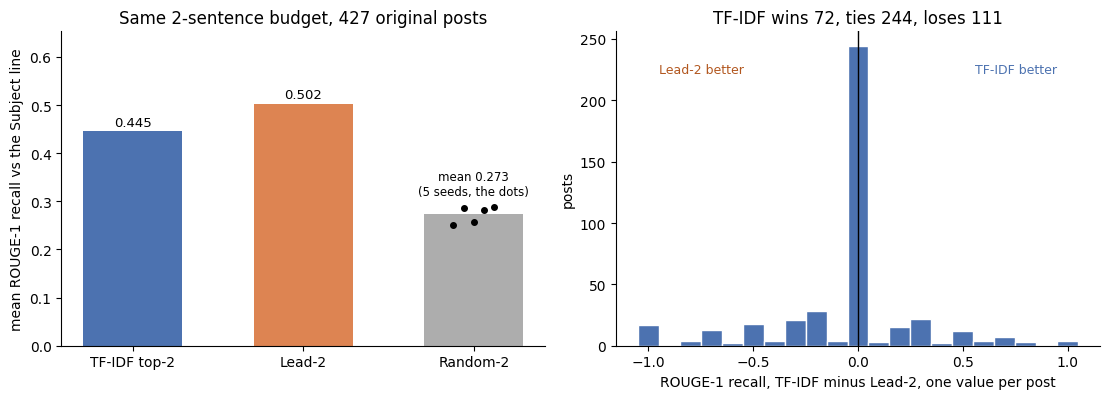

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.1))

names = ["TF-IDF top-2", "Lead-2", "Random-2"]
means = [tfidf_r.mean(), lead_r.mean(), random_means.mean()]
a1.bar(names, means, width=0.58, color=["#4C72B0", "#DD8452", "0.68"])
a1.scatter(np.full(5, 2) + np.linspace(-0.12, 0.12, 5), random_means, s=16, color="black", zorder=3)
for x, m in enumerate(means[:2]):
    a1.text(x, m + 0.012, f"{m:.3f}", ha="center", fontsize=9.5)
a1.text(2, random_means.max() + 0.025, f"mean {means[2]:.3f}\n(5 seeds, the dots)", ha="center", fontsize=8.5)
a1.set_ylim(0, max(means) * 1.3)
a1.set_ylabel("mean ROUGE-1 recall vs the Subject line")
a1.set_title(f"Same 2-sentence budget, {len(EVAL)} original posts")
a1.spines[["top", "right"]].set_visible(False)

a2.hist(diff, bins=np.arange(-1.05, 1.1, 0.1), color="#4C72B0", edgecolor="white")   # a bin centred on 0 = ties
a2.axvline(0, color="black", lw=1)
a2.set_xlabel("ROUGE-1 recall, TF-IDF minus Lead-2, one value per post")
a2.set_ylabel("posts")
a2.set_title(f"TF-IDF wins {int((diff > 0).sum())}, ties {int((diff == 0).sum())}, loses {int((diff < 0).sum())}")
a2.text(-0.95, a2.get_ylim()[1] * 0.9, "Lead-2 better", fontsize=9, color="#B2571F", va="top")
a2.text(0.95, a2.get_ylim()[1] * 0.9, "TF-IDF better", fontsize=9, color="#4C72B0", va="top", ha="right")
a2.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Read the figure.** *Left:* three summarizers, one budget, one reference. Random-2 sits at about 0.27, and its
five seeds land within a few hundredths of each other — so a gap of 0.15 or more between the other two methods
and random is real, not luck. Both real methods clear it. But the bar that should worry you is the orange one:
**Lead-2 scores higher than the TF-IDF summarizer**, 0.50 against 0.45. *Right:* the same comparison post by
post. The tall spike at zero is the majority of posts on which the two methods tie — usually because both
found the same Subject words, or neither did. Of the posts that are not ties, more go to Lead-2 than to
TF-IDF. The length table printed above says the ordering holds in every length band.

This is not an artefact of Usenet. When See, Liu and Manning (2017) built a pointer-generator network for
news summarization, their best model scored 39.53 ROUGE-1 and the lead-3 baseline scored 40.34 (their
Table 1): the first three sentences beat the neural network. Authors front-load what matters; a summarizer
that ignores position throws that away. The lesson is not "use Lead-2". The lesson is that **you did not
know which method was better until you measured it, and the measurement contradicted the sophistication
ranking.** Build the baseline first. Always.

### Now the question-answering baseline, measured

Twelve questions written against posts in this corpus. For ten of them the answer exists in one sentence of
one post, so the label is *(the post's Subject, a phrase the returned sentence must contain)*. Two have **no
answer anywhere in the corpus** — the retriever will return something for them anyway, with a score.

In [7]:
QUESTIONS = [
    # (question, Subject of the post holding the answer, phrase the top sentence must contain)
    ("What is a Doctor of Osteopathy?",
     "What's the Difference Between an M.D. and a D.O.?", "Doctor of Osteopathy"),
    ("When was the Hubble telescope launched?",
     "HST Servicing Mission Scheduled for 11 Days", "April 1990"),
    ("Which Galileo instruments had memory readouts performed on April 19?",
     "Galileo Update - 04/22/93", "Dust Detector"),
    ("Which antenna was used for the suppressed carrier receiver characterization test?",
     "Galileo Update - 04/22/93", "DSS-14"),
    ("How many EVAs are scheduled for the Hubble servicing mission?",
     "HST Servicing Mission Scheduled for 11 Days", "five"),
    ("How much does it cost to rent a car from Alamo for a week?",
     "Renting from Alamo", "$225"),
    ("What did the dictionary say osteopathy is?",
     "What's the Difference Between an M.D. and a D.O.?", "manipulative techniques"),
    ("What does D.O. stand for?",
     "What's the Difference Between an M.D. and a D.O.?", "Doctor of Osteopathy"),
    ("What is the placebo effect?",
     "Placebo effects", "belief in the medicine"),
    ("How many hours is the Galileo command loss timer set to?",
     "Galileo Update - 04/22/93", "264 hours"),
    ("Is the Beretta a good rental car?", None, None),                  # nobody in the corpus answers this
    ("What is the price of a Toyota Corolla in Riyadh?", None, None),   # nor this
]

# Guard: every labelled Subject must exist, or the score below would be measuring a typo.
for _, subj, _ in QUESTIONS:
    if subj is not None:
        find_post(subj)

hits = 0
for question, gold_subject, gold_phrase in QUESTIONS:
    sent, subj, score = answer(question, k=1)[0]
    if gold_subject is None:
        verdict = "NO ANSWER EXISTS"
    elif subj == gold_subject and gold_phrase.lower() in sent.lower():
        verdict, hits = "hit", hits + 1
    else:
        verdict = "MISS"
    print("=" * 96)
    print(f"{verdict:<17} score {score:.3f}   Q: {question}")
    print(f"{'':<17} index sees: {analyzer(question)}")
    print(f"{'':<17} top sentence [{subj[:40]}]: {sent[:118]}{'...' if len(sent) > 118 else ''}")

answerable = sum(g is not None for _, g, _ in QUESTIONS)
print("\n" + "=" * 96)
print(f"hit@1 = {hits} of {answerable} answerable questions ({hits / answerable:.0%}); "
      f"the {len(QUESTIONS) - answerable} unanswerable questions were answered anyway.")
print("Read this honestly: 10 questions means each one is worth 10 percentage points.")

hit               score 0.785   Q: What is a Doctor of Osteopathy?
                  index sees: ['doctor', 'osteopathy']
                  top sentence [What's the Difference Between an M.D. an]: However, I discovered that she is actually not an Medical Doctor (M.D.) but rather a "Doctor of Osteopathy" (D.O.).
hit               score 0.412   Q: When was the Hubble telescope launched?
                  index sees: ['hubble', 'telescope', 'launched']
                  top sentence [HST Servicing Mission Scheduled for 11 D]: The telescope was launched aboard Discovery in April 1990.
hit               score 0.488   Q: Which Galileo instruments had memory readouts performed on April 19?
                  index sees: ['galileo', 'instruments', 'memory', 'readouts', 'performed', 'april', '19']
                  top sentence [Galileo Update - 04/22/93]: On April 19, cruise science Memory Readouts (MROs) were performed for the Extreme Ultraviolet Spectrometer (EUV), Dust...
hit               s

**Read the table line by line — and start with a hit that should not comfort you.**

- **"How many EVAs..."** counts as a hit: the returned sentence really does contain "five spacewalks". Now
  look at which sentence it is — the 64-word press-release header from Part 1, glued to the first real
  sentence by the splitter. The answer is in there because the splitter failed, not because the retriever
  understood the question. *A hit@1 of 1 cannot tell luck from skill; only reading the output can.*

**Now the misses — each one is a different mechanism, and the `index sees` line shows it.**

- **"How much does it cost to rent a car from Alamo..."** — the price ("$225 for a week") sits in a sentence
  that never says *Alamo*, *rent* or *car*; those words live in the sentences around it. *Answers are spread
  across sentences; a one-sentence retriever cannot join them.*
- **"What did the dictionary say osteopathy is?"** — the winner is *"What did you say your name was?"*. It
  shares *did* and *say*; the right sentence says *says*, which is a different string because there is no
  stemming; and the winner has only two content words, so cosine scores it as a near-perfect match. *Short
  sentences full of common words beat long sentences with the rare one.*
- **"What does D.O. stand for?"** — `index sees: ['does', 'stand']`. The tokenizer from Unit 1 keeps tokens of
  two or more letters, so "D.O." vanished before retrieval began. *The question was destroyed at
  tokenization; no retriever could recover it.*
- **"What is the placebo effect?"** and **"...command loss timer..."** — both return a sentence that *asks* the
  question. The definitions exist, lower in the ranking. *A lexical index cannot tell a question from an
  answer.*
- **"Is the Beretta a good rental car?"** — score **1.000**, the maximum possible, for a sentence that is the
  question itself, written by someone who did not know either. This is the pizza-glue failure in miniature:
  nothing in the score distinguishes "found the answer" from "found the same words".
- **"...Toyota Corolla in Riyadh?"** — no post mentions Riyadh; the retriever returns "The Corolla never
  entered my mind" at 0.458. There is no threshold that separates this from the correct Hubble answer at
  0.412 in the same table. *The score is a similarity, not a confidence.*

Five hits out of ten is not a bad baseline for zero training and zero cost — but it is a **baseline**, one of
the five was luck, and now you know exactly what the next system has to fix, one mechanism at a time.

In [8]:
# One number for the build-or-buy conversation: how much text would leave the machine per post
# if this job were sent to a hosted model instead of run locally for free.
try:
    import transformers
    transformers.logging.set_verbosity_error()
    tok = transformers.AutoTokenizer.from_pretrained("gpt2", local_files_only=True)
    tok.model_max_length = 10 ** 9                  # silences the "longer than 1024" notice; no model is run
    count, unit = (lambda s: len(tok.encode(s))), "GPT-2 BPE tokens (cached tokenizer, no network)"
except Exception:                                   # no cached tokenizer on this machine
    count, unit = (lambda s: len(s.split())), "whitespace words (BPE would count roughly 30% more)"

post_tokens = np.array([count(bodies.data[i]) for i in EVAL])
summary_tokens = np.array([count(" ".join(summarize(i))) for i in EVAL])

print(f"unit: {unit}")
print(f"per post, median : {np.median(post_tokens):.0f} tokens in, {np.median(summary_tokens):.0f} tokens in the 2-sentence summary")
print(f"all {len(EVAL)} posts    : {post_tokens.sum():,} tokens would be sent as input to a hosted summarizer")
print(f"this notebook    : 0 tokens sent anywhere; every post stayed on this machine")
print("\nMultiply the total by the current price per million input tokens of the model you would buy —")
print("look it up on the day, it changes — and you have the per-run cost of the alternative to Part 1.")

unit: GPT-2 BPE tokens (cached tokenizer, no network)
per post, median : 201 tokens in, 68 tokens in the 2-sentence summary
all 427 posts    : 318,774 tokens would be sent as input to a hosted summarizer
this notebook    : 0 tokens sent anywhere; every post stayed on this machine

Multiply the total by the current price per million input tokens of the model you would buy —
look it up on the day, it changes — and you have the per-run cost of the alternative to Part 1.


## 💬 Discuss

1. The first two sentences beat the TF-IDF summarizer here, as the first three beat a neural network on news
   in 2017. A manager asks you to "add AI summaries" to an internal document tool. What is the baseline you
   build *first*, what number would you have to show to justify anything more expensive, and what do you say
   about the 57% of posts on which the two methods tied?
2. The reference was the author's Subject line: free, human, and often unfit — it excluded every reply, it
   is three words long, and the tokenizer counts "04", "22" and "93" as content words of a Galileo status
   report. If you had budget for fifty human-written summaries, which fifty posts would you choose, and what
   would that choice do to the denominator you could honestly claim afterwards?
3. "Is the Beretta a good rental car?" scored 1.000 against a sentence that answers nothing; Google served an
   eleven-year-old joke as pizza advice with a straight face. Name the check a system must run *between* "best
   matching passage" and "answer shown to the user". Who owns that check — the model, the retriever, the
   product team — and who is accountable when it is missing?
4. Build or buy. Part 1 costs nothing per call, needs no network, and the text never leaves the machine. A
   hosted model would likely summarize better and would charge per token on every call, with the whole post as
   input — you printed the count. For a Saudi hospital's internal notes, which side of the PDPL Article 29
   transfer rules from Course 06 Unit 3 (`04_gdpr_compliance.ipynb`) does each option fall on, and does the
   answer change if the "posts" are car-rental reviews instead?

---

## ✅ Summary

**What you did here** (every number computed live above):

- Loaded **1,781 real 1993 Usenet posts** from the local cache, split them into sentences, and saw what real
  text looks like before any model touches it.
- Built an **extractive summarizer** from Unit 3's `TfidfVectorizer` and cosine similarity — no training, no
  new library — and watched it over-value a press-release header full of rare tokens.
- Turned the same vectorizer into a **sentence retriever** that answers questions, and printed the words the
  index actually sees after tokenization and stop-word removal.
- **Evaluated** the summarizer against the human-written Subject line on **427 original posts** with ROUGE-1
  recall and a fixed two-sentence budget: **Lead-2 0.502 beat TF-IDF 0.445**, both far above Random-2
  (about 0.27, stable across five seeds). The sophisticated method lost to the baseline.
- **Evaluated** the retriever on twelve labelled questions: **5 of 10** answerable questions hit — one of them
  because the sentence splitter failed — and each miss printed its own mechanism: answers split across
  sentences, no stemming plus a short-sentence bias, an abbreviation destroyed by the tokenizer, questions
  returned as answers, and a perfect 1.000 for a sentence that answers nothing.
- Counted the tokens a hosted alternative would be sent per post, so the build-or-buy argument has a number.

**The transferable habit:** reference, metric, denominator, baseline — stated *before* the result, so that
a result you did not want cannot be quietly dropped.

## ⚠️ Where this breaks

**The reference is a proxy, and the metric counts words.** A Subject line is typically three words written
before the post; ROUGE-1 recall against it rewards a summary for repeating those words and nothing else. About
one post in five scored exactly zero under each method, and 52 of the 427 scored zero under *both* — Subjects
like "Why isolate it?", "HYPOGLYCEMIA" and "Boom! Whoosh......", whose words never appear in the two chosen
sentences however they are chosen. A higher ROUGE does not mean a more useful summary; it means more shared tokens.
Before you report a ROUGE number to anyone, say what the reference was and who wrote it.

**Extractive summaries cannot say what the document does not say in one sentence.** Part 1 copies sentences.
If the point of a post is spread across three sentences, or is only implied, no extractive method reaches it.
The obvious next step — an abstractive model that writes new sentences — is not a free upgrade: Maynez et al.
(2020) had human annotators read the output of several neural abstractive summarizers and found *"substantial
amounts of hallucinated content in all model generated summaries"*, content *"unfaithful to the input
document"*. You trade "misses the point" for "invents a point", and only an evaluation like Part 3 tells you
which trade you made.

**A similarity score is not a confidence.** The retriever returned 1.000 for a sentence that answers nothing
and 0.412 for a correct answer. There is no threshold on this score that separates "answered" from "matched".
The named case: Google's AI Overviews, May 2024, served a Reddit joke as pizza advice because it was the
best-matching passage, and Google's own explanation was a *"data void"* — exactly the Riyadh question above.
The retriever was not wrong; the system had no step that asked whether the match was an answer.

**The assumption that must hold:** the answer is one sentence, and it shares vocabulary with the question.
Synonyms (*spacewalk* / *EVA*), abbreviations (*D.O.*), morphology (*say* / *says*) and split answers all
break it, and Unit 4's contextual embeddings exist precisely because this assumption fails on real questions.

**When to reach for something cheaper:** if the documents are news-like or memo-like, **show the first two
sentences** — it beat the method in this notebook and costs nothing to maintain. If users ask the same twenty
questions, a hand-written FAQ is more accurate than any retriever and can be fixed in one edit. Not every text
problem needs a model, and the evaluation you ran is how you find out.

## 🔭 State of the field (2026)

The two halves of this notebook are the two halves of a retrieval-augmented system: a retriever chooses
passages, a generator writes over them. What changed since 1993 is the generator; what did *not* change is
that the retriever still ranks by similarity and still has no idea whether a match is an answer, which is why
the AI Overviews failure in 2024 looked exactly like the Beretta question here. Production systems now add
what this notebook deliberately left out — a re-ranker, an "is this answerable?" check, and a citation shown
to the user — and the sentence-level index you built is the first stage those sit on. Evaluation moved the
other way: it is now common to have a large model *grade* summaries instead of counting words, and Unit 3's
"⚠️" already pointed you at the measured inconsistency of that instrument. The discipline is unchanged:
reference, metric, denominator, baseline, stated before the result.

## 📚 References

Each of these is used in the body above; none is decoration.

1. Luhn, H. P. (1958). *The Automatic Creation of Literature Abstracts.* IBM Journal of Research and
   Development, 2(2), 159–165. — the original extractive method (Part 1's "significance factor").
2. Lin, C.-Y. (2004). *ROUGE: A Package for Automatic Evaluation of Summaries.* Text Summarization Branches
   Out (ACL workshop), 74–81. <https://aclanthology.org/W04-1013/> — the metric in Part 3.
3. See, A., Liu, P. J., & Manning, C. D. (2017). *Get To The Point: Summarization with Pointer-Generator
   Networks.* ACL 2017. <https://arxiv.org/abs/1704.04368> — Table 1: lead-3 baseline 40.34 ROUGE-1 against
   39.53 for the best model (the "baseline beats the model" evidence under Figure 2).
4. Maynez, J., Narayan, S., Bohnet, B., & McDonald, R. (2020). *On Faithfulness and Factuality in Abstractive
   Summarization.* ACL 2020. <https://arxiv.org/abs/2005.00661> — the hallucination finding in "⚠️".
5. Reid, E. (2024, May 30). *AI Overviews: About last week.* Google, The Keyword.
   <https://blog.google/products/search/ai-overviews-update-may-2024/> — Google's own account of the
   forum-advice and "data void" mechanisms.
6. Daily Dot (2024, May 23). *Google's new AI search pulls answers from decades-old Reddit troll post —
   suggesting glue on pizza.* <https://dailydot.com/google-search-results-reddit-pizza-glue-cheese> — the
   quoted "⅛ cup of non-toxic glue" Overview and its eleven-year-old Reddit source.